### 🔹 Let's work with Vendor Report  
Preview

<img src="assets/vendor_pdf_side_by_side.png" height="300">

## Method 1 - Captioning the image using LLMs

### Load PDF using PymuPDF (fitz)

In [1]:
import fitz

pdf_path = "data-reports/vendor_report.pdf"
doc = fitz.open(pdf_path)

print("Total pages:", len(doc))

Total pages: 3


### Count Images per page along with its x-y coordinate
- Coordinates will be needed to later merge them together.

In [2]:
for page_num, page in enumerate(doc):
    images = page.get_images(full=True)

    for img_index, img in enumerate(images):
        bbox = page.get_image_bbox(img)
        print(
            f"Page {page_num+1}, Image {img_index+1} -> "
            f"x0={bbox.x0:.2f}, y0={bbox.y0:.2f}"
        )

Page 1, Image 1 -> x0=117.64, y0=187.60
Page 2, Image 1 -> x0=117.64, y0=187.60
Page 3, Image 1 -> x0=117.64, y0=187.60


### Function to generate captions to images

In [7]:
import base64
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage

load_dotenv()

llm = ChatOpenAI(model="gpt-4o")

def caption_image(image_bytes):
    b64 = base64.b64encode(image_bytes).decode("utf-8")

    message = HumanMessage(
        content=[
            {
                "type": "image_url",
                "image_url": {
                    "url": f"data:image/png;base64,{b64}"
                }
            },
            {
                "type": "text",
                "text": "Describe this image concisely for a RAG system."
            }
        ]
    )

    response = llm.invoke([message])
    return response.content

### Visualize the images along with respective captions.


========== PAGE 1 ==========


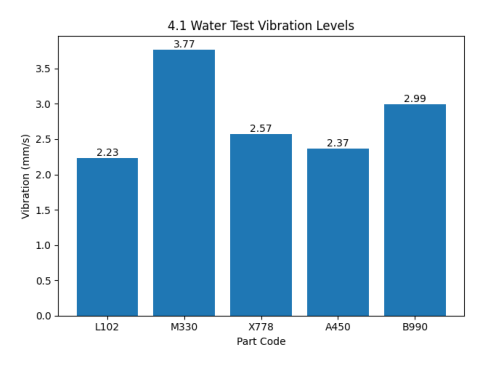


--- Image 1 Caption ---
Bar chart titled "4.1 Water Test Vibration Levels" displaying vibration levels (mm/s) for different part codes. The vibration levels are: L102 (2.23), M330 (3.77), X778 (2.57), A450 (2.37), and B990 (2.99). M330 has the highest vibration level.

========== PAGE 2 ==========


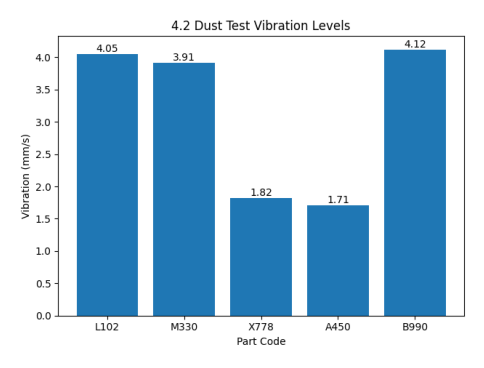


--- Image 1 Caption ---
Bar chart titled "4.2 Dust Test Vibration Levels" showing vibration (mm/s) for different part codes: L102 (4.05), M330 (3.91), X778 (1.82), A450 (1.71), B990 (4.12).

========== PAGE 3 ==========


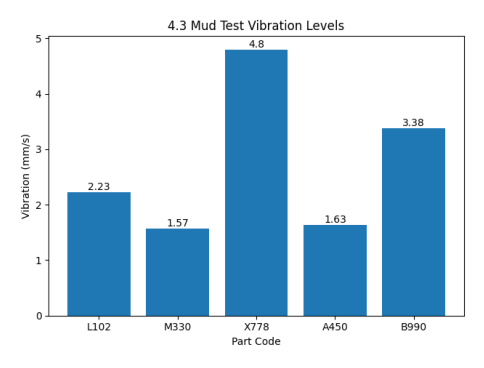


--- Image 1 Caption ---
Bar chart titled "4.3 Mud Test Vibration Levels" showing vibration (mm/s) for different part codes: L102 (2.23), M330 (1.57), X778 (4.8), A450 (1.63), B990 (3.38).


In [5]:
import fitz
import base64
from PIL import Image
import matplotlib.pyplot as plt

def caption_all_images(pdf_path):
    doc = fitz.open(pdf_path)

    for page_num, page in enumerate(doc):
        images = page.get_images(full=True)

        print(f"\n========== PAGE {page_num+1} ==========")

        for img_index, img in enumerate(images):
            xref = img[0]
            img_data = doc.extract_image(xref)
            image_bytes = img_data["image"]

            # --- Display Image ---
            pix = fitz.Pixmap(doc, xref)
            img_pil = Image.frombytes("RGB", [pix.width, pix.height], pix.samples)

            plt.figure(figsize=(6, 6))
            plt.imshow(img_pil)
            plt.axis("off")
            plt.show()

            # --- Generate Caption ---
            caption = caption_image(image_bytes)

            print(f"\n--- Image {img_index+1} Caption ---")
            print(caption)


# Usage
pdf_path = "data-reports/vendor_report.pdf"
caption_all_images(pdf_path)